<a href="https://colab.research.google.com/github/sundaram0900/Employee_salary-prediction-using-SVR/blob/Master/Employee_salary_predection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score,r2_score,mean_squared_error

#Importing the Dataset

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/Lochana24/Baltimore-Salary-Prediction/main/train.csv"
df = pd.read_csv(url)
df.head()


,Name,JobTitle,AgencyID,Agency,HireDate,AnnualSalary,GrossPay
0,"Aaron,Keontae E",AIDE BLUE CHIP,W02200,Youth Summer,06/10/2013,$11310.00,$873.63
1,"Aaron,Patricia G",Facilities/Office Services II,A03031,OED-Employment Dev,10/24/1979,$53428.00,$52868.38
2,"Aaron,Petra L",ASSISTANT STATE'S ATTORNEY,A29005,States Attorneys Office,09/25/2006,$68300.00,$67439.19
3,"Abaineh,Yohannes T",EPIDEMIOLOGIST,A65026,HLTH-Health Department,07/23/2009,$62000.00,$58654.74
4,"Abbene,Anthony M",POLICE OFFICER TRAINEE,A99416,Police Department,07/24/2013,$43999.00,$39686.95


#problem statement

given a dataset which captures the salary from july 1st 2013 to june 30 2014 it includes only those employees who are employed on june 20 2014 predict the salary of employees working in batlimore.

In [6]:
df.tail()

,Name,JobTitle,AgencyID,Agency,HireDate,AnnualSalary,GrossPay
18976,"Zotamou,Jean Marie D",AIDE BLUE CHIP,W02235,Youth Summer,05/21/2014,$11310.00,NaN
18977,"Zotamou,Pivot D",AIDE BLUE CHIP,W02629,Youth Summer,05/21/2014,$11310.00,NaN
18978,"Zovistoski,Zachary D",POLICE OFFICER TRAINEE,A99416,Police Department,12/17/2013,$43999.00,$21070.03
18979,"Zubyk,Stanislav T",POLICE OFFICER,A99262,Police Department,01/23/2013,$44104.00,$48608.12
18980,"Zukowski,Charles J",Waste Water Tech Supv I Pump,A50206,DPW-Water & Waste Water,10/15/1979,$53568.00,$52164.32


In [7]:
df.shape

(18981, 7)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18981 entries, 0 to 18980
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0    Name         18981 non-null  object
 1   JobTitle      18981 non-null  object
 2   AgencyID      18981 non-null  object
 3   Agency        18981 non-null  object
 4   HireDate      18911 non-null  object
 5   AnnualSalary  18981 non-null  object
 6   GrossPay      15758 non-null  object
dtypes: object(7)
memory usage: 1.0+ MB


In [9]:
df.describe()

,Name,JobTitle,AgencyID,Agency,HireDate,AnnualSalary,GrossPay
count,18981,18981,18981,18981,18911,18981,15758
unique,18788,1075,1177,65,4737,1590,13732
top,"Battle,Daron J",AIDE BLUE CHIP,P04001,Youth Summer,05/21/2014,$11310.00,$1051.25
freq,2,4817,316,4323,1478,4811,848


In [10]:
df.columns

Index([' Name', 'JobTitle', 'AgencyID', 'Agency', 'HireDate', 'AnnualSalary',
       'GrossPay'],
      dtype='object')

In [11]:
newdf=df.copy()

In [12]:
newdf.columns = newdf.columns.str.strip().str.lower()

In [13]:
newdf.columns

Index(['name', 'jobtitle', 'agencyid', 'agency', 'hiredate', 'annualsalary',
       'grosspay'],
      dtype='object')

In [14]:
newdf.head()

,name,jobtitle,agencyid,agency,hiredate,annualsalary,grosspay
0,"Aaron,Keontae E",AIDE BLUE CHIP,W02200,Youth Summer,06/10/2013,$11310.00,$873.63
1,"Aaron,Patricia G",Facilities/Office Services II,A03031,OED-Employment Dev,10/24/1979,$53428.00,$52868.38
2,"Aaron,Petra L",ASSISTANT STATE'S ATTORNEY,A29005,States Attorneys Office,09/25/2006,$68300.00,$67439.19
3,"Abaineh,Yohannes T",EPIDEMIOLOGIST,A65026,HLTH-Health Department,07/23/2009,$62000.00,$58654.74
4,"Abbene,Anthony M",POLICE OFFICER TRAINEE,A99416,Police Department,07/24/2013,$43999.00,$39686.95


In [16]:
newdf.isnull().sum()

,0
name,0
jobtitle,0
agencyid,0
agency,0
hiredate,70
annualsalary,0
grosspay,3223


In [18]:
# Delete the coloumn grosspay
newdf.drop('grosspay', axis=1, inplace=True)

In [19]:
newdf.columns

Index(['name', 'jobtitle', 'agencyid', 'agency', 'hiredate', 'annualsalary'], dtype='object')

In [20]:
newdf.agencyid

,agencyid
0,W02200
1,A03031
2,A29005
3,A65026
4,A99416
...,...
18976,W02235
18977,W02629
18978,A99416
18979,A99262


In [21]:
newdf.agencyid.value_counts()

,count
agencyid,
P04001,316
C90786,276
W02629,193
P04002,191
A99416,166
...,...
W02539,1
A65052,1
W02106,1


In [22]:
newdf.annualsalary.value_counts()

,count
annualsalary,
$11310.00,4811
$20800.00,325
$29245.00,196
$43999.00,169
$44773.00,163
...,...
$116300.00,1
$83500.00,1
$40994.00,1


In [32]:
newdf['annualsalary'] = newdf['annualsalary'].astype(float)


In [33]:
newdf['annualsalary']

,annualsalary
0,11310.0
1,53428.0
2,68300.0
3,62000.0
4,43999.0
...,...
18976,11310.0
18977,11310.0
18978,43999.0
18979,44104.0


In [39]:
# now split the hiredate into hire day hire month and hire year and convert them to integer and these should be in place of hiredate
newdf['hiredate'] = pd.to_datetime(newdf['hiredate'])
newdf['hireday'] = newdf['hiredate'].dt.day
newdf['hiremonth'] = newdf['hiredate'].dt.month
newdf['hireyear'] = newdf['hiredate'].dt.year
newdf.drop('hiredate', axis=1, inplace=True)
newdf.head()

,name,jobtitle,agencyid,agency,annualsalary,hireday,hiremonth,hireyear
0,"Aaron,Keontae E",AIDE BLUE CHIP,W02200,Youth Summer,11310.0,10.0,6.0,2013.0
1,"Aaron,Patricia G",Facilities/Office Services II,A03031,OED-Employment Dev,53428.0,24.0,10.0,1979.0
2,"Aaron,Petra L",ASSISTANT STATE'S ATTORNEY,A29005,States Attorneys Office,68300.0,25.0,9.0,2006.0
3,"Abaineh,Yohannes T",EPIDEMIOLOGIST,A65026,HLTH-Health Department,62000.0,23.0,7.0,2009.0
4,"Abbene,Anthony M",POLICE OFFICER TRAINEE,A99416,Police Department,43999.0,24.0,7.0,2013.0


In [35]:
newdf.head()

,name,jobtitle,agencyid,agency,hiredate,annualsalary
0,"Aaron,Keontae E",AIDE BLUE CHIP,W02200,Youth Summer,2013-06-10,11310.0
1,"Aaron,Patricia G",Facilities/Office Services II,A03031,OED-Employment Dev,1979-10-24,53428.0
2,"Aaron,Petra L",ASSISTANT STATE'S ATTORNEY,A29005,States Attorneys Office,2006-09-25,68300.0
3,"Abaineh,Yohannes T",EPIDEMIOLOGIST,A65026,HLTH-Health Department,2009-07-23,62000.0
4,"Abbene,Anthony M",POLICE OFFICER TRAINEE,A99416,Police Department,2013-07-24,43999.0


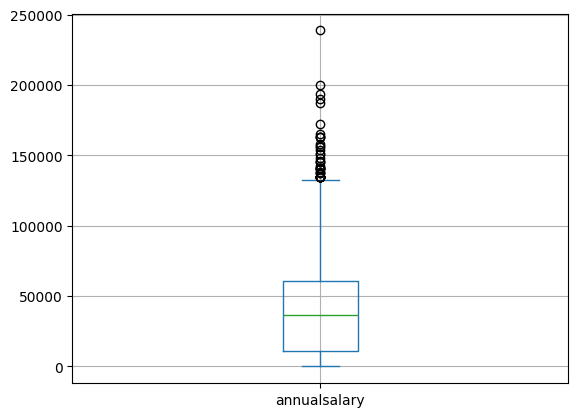

In [42]:
#Box-plot
newdf.annualsalary.plot.box()
plt.grid()

<Axes: xlabel='jobtitle'>

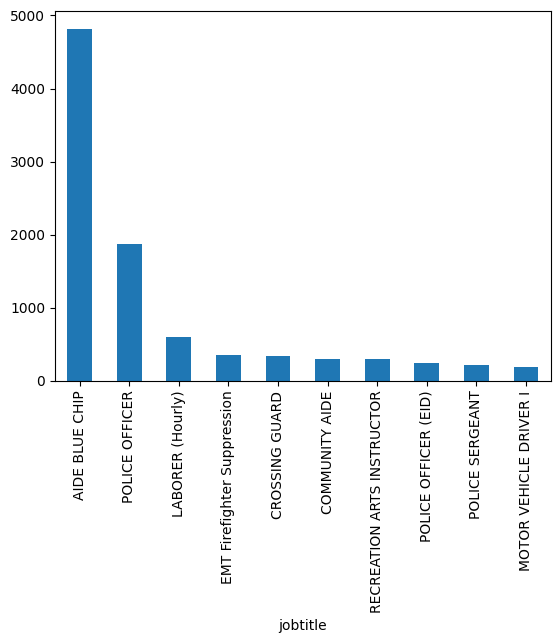

In [43]:
#ploting top 10 jobs based on hiring
newdf.jobtitle.value_counts().head(10).plot.bar()

<Axes: xlabel='jobtitle'>

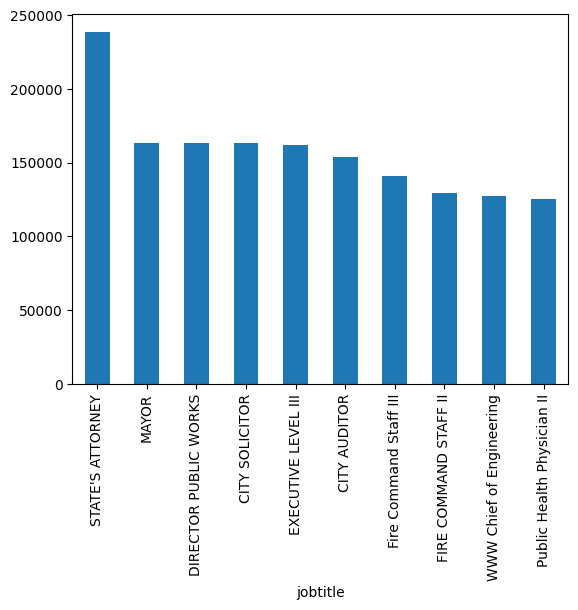

In [44]:
# ploting top 10 jobs with heighest salary
newdf.groupby('jobtitle')['annualsalary'].mean().sort_values(ascending=False).head(10).plot.bar()

<Axes: xlabel='agencyid'>

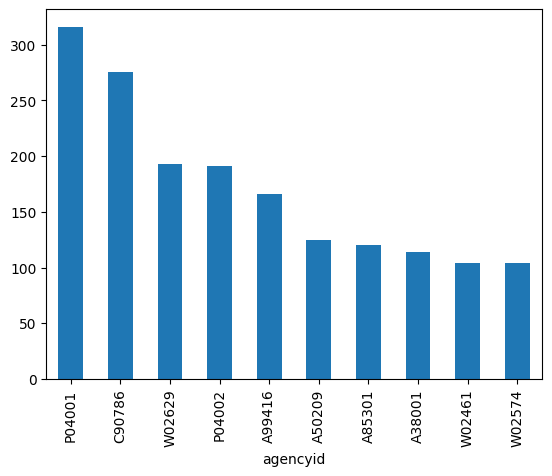

In [45]:
# plot top 10 agences id that has heighest number of employees
newdf.agencyid.value_counts().head(10).plot.bar()

In [46]:
# show the each agency count
newdf.agencyid.value_counts()

,count
agencyid,
P04001,316
C90786,276
W02629,193
P04002,191
A99416,166
...,...
W02539,1
A65052,1
W02106,1


<Axes: xlabel='agency'>

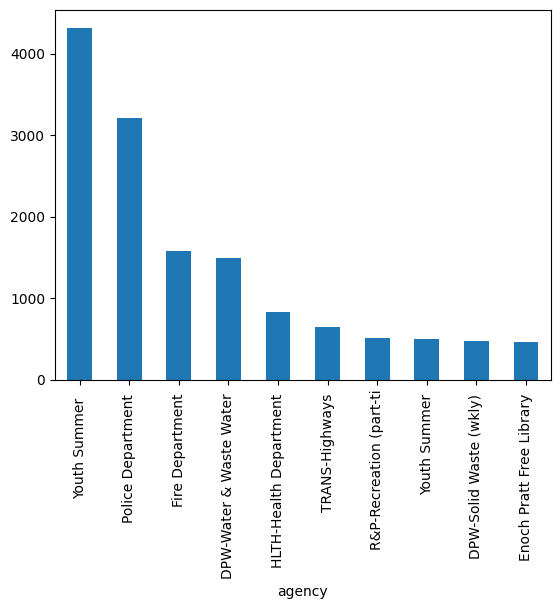

In [48]:
# plot the graph for top 10 agencey names on heighest number of employees
newdf.agency.value_counts().head(10).plot.bar()

<Axes: xlabel='hireyear'>

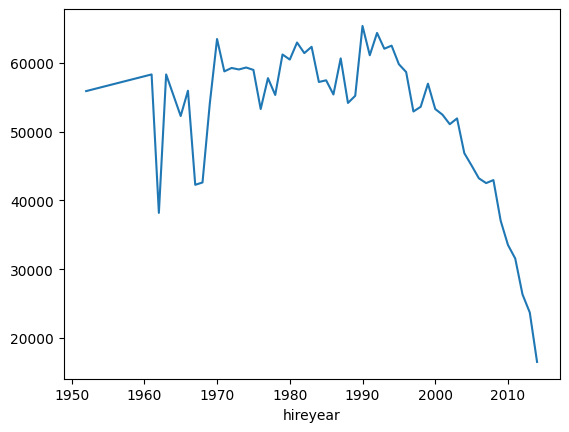

In [50]:
# plot the  heighets salary vs year graph
newdf.groupby('hireyear')['annualsalary'].mean().plot()

<Axes: xlabel='hireyear'>

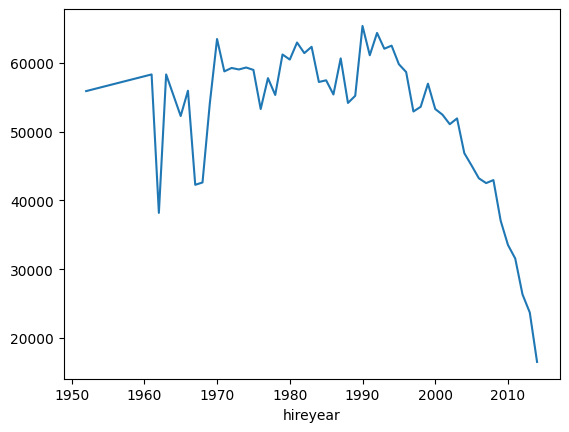

In [51]:
#plot the average salary vs year
newdf.groupby('hireyear')['annualsalary'].mean().plot()

<Axes: xlabel='hiremonth'>

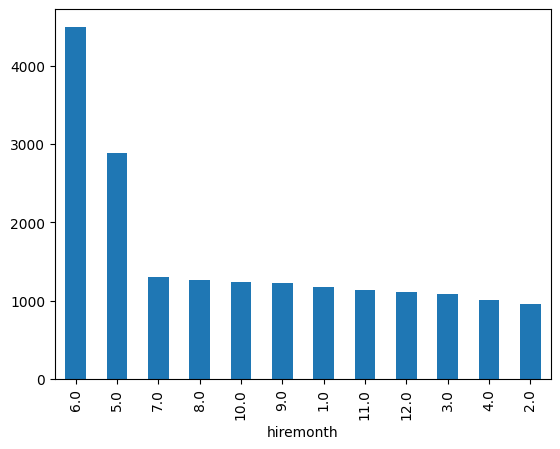

In [52]:
# plot graph for in which moth most of the employyes are heired
newdf.hiremonth.value_counts().plot.bar()

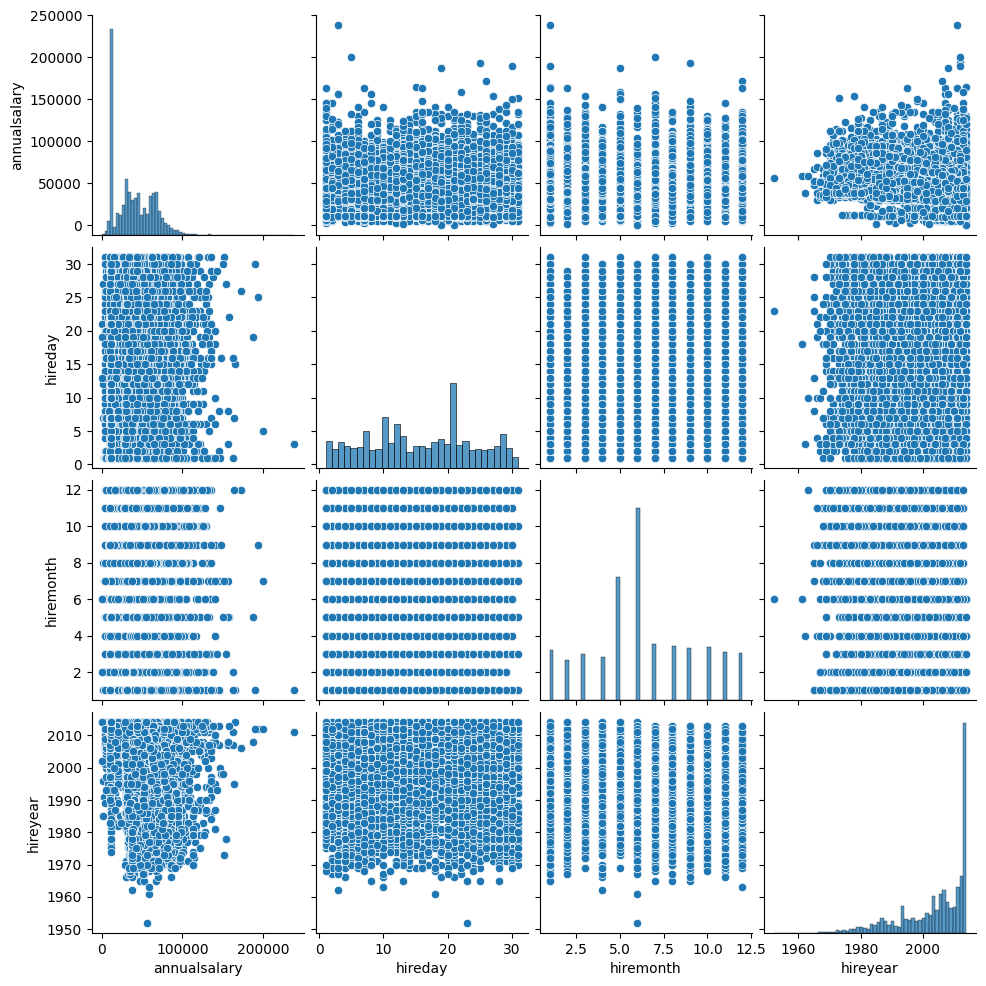

In [53]:
# plot a pairplot
#A pairplot is a type of visualization in Seaborn, a Python data visualization library. It creates a grid of scatter plots and histograms to show relationships between multiple numerical variables in a dataset.
sns.pairplot(newdf)

In [59]:
newdf.head()

,jobtitle,agencyid,agency,annualsalary,hireday,hiremonth,hireyear
0,AIDE BLUE CHIP,W02200,Youth Summer,11310.0,10.0,6.0,2013.0
1,Facilities/Office Services II,A03031,OED-Employment Dev,53428.0,24.0,10.0,1979.0
2,ASSISTANT STATE'S ATTORNEY,A29005,States Attorneys Office,68300.0,25.0,9.0,2006.0
3,EPIDEMIOLOGIST,A65026,HLTH-Health Department,62000.0,23.0,7.0,2009.0
4,POLICE OFFICER TRAINEE,A99416,Police Department,43999.0,24.0,7.0,2013.0


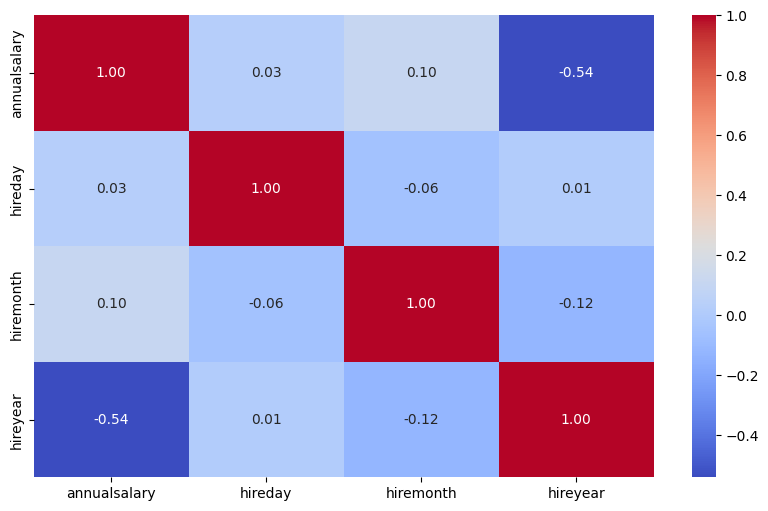

In [61]:
# plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = newdf.select_dtypes(include=['number'])

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()


#Machine learning

In [62]:
# Train test split
X = newdf.drop('annualsalary', axis=1)
y = newdf['annualsalary']

In [64]:
# Data preprocessing - Feauture scaling
scaler = StandardScaler()
X = scaler.fit_transform(numeric_df)


In [69]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


In [70]:
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)


In [71]:
#performance metrices
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [72]:
#print the accuracy
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 562685949.000029
R-squared: 0.09897181383689035


In [74]:
newdf.head()

,jobtitle,agencyid,agency,annualsalary,hireday,hiremonth,hireyear
0,AIDE BLUE CHIP,W02200,Youth Summer,11310.0,10.0,6.0,2013.0
1,Facilities/Office Services II,A03031,OED-Employment Dev,53428.0,24.0,10.0,1979.0
2,ASSISTANT STATE'S ATTORNEY,A29005,States Attorneys Office,68300.0,25.0,9.0,2006.0
3,EPIDEMIOLOGIST,A65026,HLTH-Health Department,62000.0,23.0,7.0,2009.0
4,POLICE OFFICER TRAINEE,A99416,Police Department,43999.0,24.0,7.0,2013.0


In [79]:
# Ensure new_data has the same columns as the original dataset
expected_columns = ['jobtitle', 'agencyid', 'agency', 'annualsalary', 'hireday', 'hiremonth', 'hireyear']

# Create new_data with the correct structure
new_data = pd.DataFrame({

    'hireday': [2],
    'hiremonth': [9],
    'hireyear': [2018]
})

# Reorder to match original dataset
new_data = new_data[expected_columns]

# Transform using the fitted scaler
new_data_scaled = scaler.transform(new_data)


KeyError: "['jobtitle', 'agencyid', 'agency', 'annualsalary'] not in index"